In [1]:
# cuda visible 
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = "1"

import torch.backends.cudnn as cudnn
cudnn.benchmark = True

In [2]:
import os 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

from CityScapes import CityscapesDataset

from DCGAN.discriminator import Discriminator
from DCGAN.encoder import Encoder
from DCGAN.reconstruction_generator import ReconstructionGenerator
from DCGAN.unet import UNet
from file_management import get_version_folder, save_config, load_config
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss, DriftLoss, EntropyLoss


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [3]:
load_run = None
config_name = 'config.yaml'

In [4]:
if load_run:
    config_path = os.path.join(load_run,config_name)
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/dcgan'
    index_folder = get_version_folder(root)
    config = load_config(config_name)
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,config_name)
    save_config(config, config_target_path)




Config saved to cache/dcgan/43/config.yaml


In [5]:
channels = config['models']['channels']
z_shape = config['models']['z_shape']
z_dim = z_shape[0]
number_of_components = config['models']['number_of_components']

enc_block_depth = config['models']['enc']['block_depth']
enc_residual = config['models']['enc']['residual']
enc_use_norm = config['models']['enc']['use_norm']

gen_block_depth = config['models']['gen']['block_depth']
gen_residual = config['models']['gen']['residual']
gen_use_norm = config['models']['gen']['use_norm']
gen_vector_dim = config['models']['gen']['vector_dim']
gen_vectorizer_linear_layer_multipliers = config['models']['gen']['linear_layer_multipliers']
gen_degrees_of_freedom = config['models']['gen']['degrees_of_freedom']

seg_gen_block_depth = config['models']['segmentation_gen']['block_depth']
seg_gen_residual = config['models']['segmentation_gen']['residual']
seg_gen_use_norm = config['models']['segmentation_gen']['use_norm']
seg_gen_cut_connections = config['models']['segmentation_gen']['cut_connections']

disc_block_depth = config['models']['disc']['block_depth']
disc_residual = config['models']['disc']['residual']
disc_use_norm = config['models']['disc']['use_norm']

batch_size = config['training']['batch_size']

enc_lr = config['training']['enc']['enc_lr']
enc_reconstruction_loss_weight = config['training']['enc']['enc_reconstruction_loss_weight']
enc_feature_loss_weight = config['training']['enc']['enc_feature_loss_weight']

gen_lr = config['training']['gen']['gen_lr']

seg_gen_lr=  config['training']['segmentation_gen']['seg_gen_lr']
seg_gen_entropy_loss_weight = config['training']['segmentation_gen']['entropy_loss_weight']

n_critic = config['training']['disc']['n_critic']
disc_lr = config['training']['disc']['disc_lr']
disc_gp_loss_weight = config['training']['disc']['disc_gp_loss_weight']
disc_drift_loss_weight = config['training']['disc']['disc_drift_loss_weight']



save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

enc_path = os.path.join(index_folder,'enc.pth')
gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')
seg_gen_path = os.path.join(index_folder,'seg_gen.pth')


tensorboard_path = os.path.join(index_folder, 'logs')
writer = SummaryWriter(log_dir=tensorboard_path)

In [6]:

enc = Encoder(channels=channels,
              block_depth=enc_block_depth,
              z_dim=z_dim,
              residual=enc_residual,
              img_channels=3,
              use_norm=enc_use_norm).to(device)

gen = ReconstructionGenerator(channels=channels,
                z_dim=z_dim,                
                number_of_components=number_of_components,
                vector_dim=gen_vector_dim,
                vectorizer_linear_layer_multipliers=gen_vectorizer_linear_layer_multipliers,
                degrees_of_freedom=gen_degrees_of_freedom,
                block_depth=enc_block_depth,
                residual=gen_residual,
                img_channels=3,
                use_norm=gen_use_norm).to(device)

seg_gen = UNet(channels=channels,
                block_depth=enc_block_depth,
                residual=gen_residual,
                number_of_components=number_of_components,
                cut_connections=seg_gen_cut_connections,
                use_norm=gen_use_norm).to(device)

disc = Discriminator(channels=channels,
                      block_depth=disc_block_depth,
                      residual=disc_residual,
                      img_channels=3,
                      use_norm=disc_use_norm).to(device)



if load_run is not None:
    enc.load_state_dict(torch.load(enc_path))
    gen.load_state_dict(torch.load(gen_path))
    seg_gen.load_state_dict(torch.load(seg_gen_path))
    disc.load_state_dict(torch.load(disc_path))





enc_optim = Adam(enc.parameters(), lr=enc_lr, betas=(0.0, 0.9))
gen_optim = Adam(gen.parameters(), lr=gen_lr, betas=(0.0, 0.9))
seg_gen_optim = Adam(seg_gen.parameters(), lr=seg_gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


tensorboard_step = 0


In [7]:
import torch

def apply_segmentation(
    tensor: torch.Tensor,
    segmentation: torch.Tensor,
    mode: str = "sum",
    normalize: bool = False,
    eps: float = 1e-6,
) -> torch.Tensor:
    """
    Combine a (b, n, rgb, h, w) tensor into (b, rgb, h, w) using a segmentation mask (b, n, h, w).

    Args:
        tensor:       (b, n, c, h, w)
        segmentation: (b, n, h, w)
        mode:         "sum" | "max"
        normalize:    If True, normalize masks across n (useful for soft masks)
        eps:          Small constant to avoid division by zero

    Returns:
        out: (b, c, h, w)
    """

    if tensor.ndim != 5:
        raise ValueError(f"tensor must be (b,n,c,h,w), got {tensor.shape}")
    if segmentation.ndim != 4:
        raise ValueError(f"segmentation must be (b,n,h,w), got {segmentation.shape}")

    b, n, c, h, w = tensor.shape

    if segmentation.shape != (b, n, h, w):
        raise ValueError("Shape mismatch between tensor and segmentation")

    # Expand segmentation to match tensor channels
    seg = segmentation.unsqueeze(2)  # (b, n, 1, h, w)

    if normalize:
        seg = seg / (seg.sum(dim=1, keepdim=True) + eps)

    masked = tensor * seg  # (b, n, c, h, w)

    if mode == "sum":
        out = masked.sum(dim=1)

    elif mode == "max":
        out = masked.max(dim=1).values

    else:
        raise ValueError(f"Unsupported mode: {mode}")

    return out

In [8]:
from DCGAN.modules.blocks.normalizations import PixelNorm
# --- HELPER FUNCTION ---
def encode_image(image):
    # 1. Independent Segmentation Path (Takes raw image because encoders are separated)
    segmentation_logits = seg_gen(image)
    segmentation = nn.Softmax(dim=1)(segmentation_logits)
    
    # 2. Independent Reconstruction Encoder Path (Unpack the tuple!)
    encoded_vector = enc(image)
    norm = PixelNorm(encoded_vector.shape[1])
    encoded_vector = norm(encoded_vector)
    # 3. Composed Generation via SPADE
    partial_reconstructions = gen(encoded_vector)

    final_reconstruction = apply_segmentation(partial_reconstructions, segmentation)
    # MUST return logits so entropy_loss_fn can use them stably
    return final_reconstruction, partial_reconstructions, segmentation, segmentation_logits

In [9]:
train_iter = iter(train_loader)

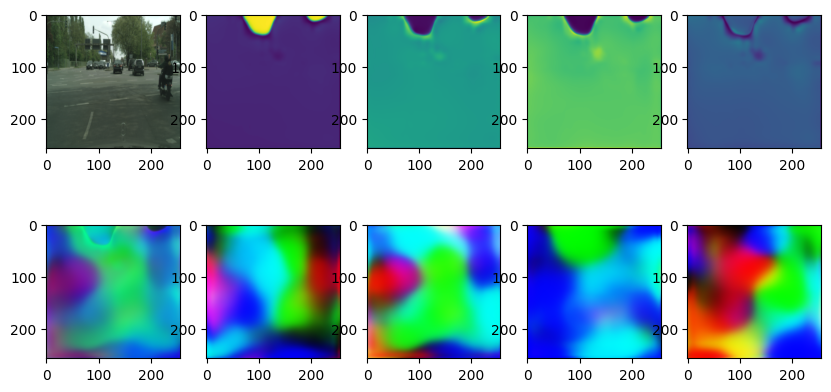

In [10]:
real ,_ = next(train_iter)
real = real.to(device)
with torch.no_grad():
    reconstruction, partial_reconstructions, segmentation, _ =      encode_image(real)
#     reconstructed_image = combine(reconstruction, segmentation)



components = segmentation.shape[1]
fig,ax = plt.subplots(2,components+1,figsize=(10,5))
real = scale_for_display(real)
ax[0,0].imshow(real[0].permute(1,2,0).cpu().numpy())
for i in range(components):
    ax[0,i+1].imshow(segmentation.cpu().numpy()[0,i])


# reconstructed_image = scale_for_display(reconstructed_image)
reconstruction = scale_for_display(reconstruction)
partial_reconstructions= scale_for_display(partial_reconstructions)
ax[1,0].imshow(reconstruction.cpu()[0].permute(1,2,0).numpy())
for i in range(components):
    ax[1,i+1].imshow(partial_reconstructions[0,i].permute(1,2,0).cpu().numpy())
plt.show()


In [11]:
partial_reconstructions.min()

tensor(1.3351e-05, device='cuda:0')

In [12]:
gp_loss_fn = GradientPenaltyLoss(weight=disc_gp_loss_weight)
drift_loss_fn=  DriftLoss(weight=disc_drift_loss_weight)
entropy_loss_fn  = EntropyLoss(weight=seg_gen_entropy_loss_weight)
reconstructions_loss_fn = WeightedMSELoss(weight=enc_reconstruction_loss_weight)

In [20]:


epochs = 100

for epoch in range(0, epochs):
    loop = tqdm(range(len(train_loader)))
    loop.set_description(f"Epoch {epoch}/{epochs}")
    
    for i in loop:
        # =====================================================================
        # 1. DISCRIMINATOR TRAINING PHASE
        # =====================================================================
        for _ in range(n_critic):
            try:
                real, _ = next(data_iter)
            except NameError: # Handle first initialization
                data_iter = iter(train_loader)
                real, _ = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                real, _ = next(data_iter)
                
            current_batch_size = real.size(0)
            real = real.to(device)
            disc_optim.zero_grad()

            # --- Real Pass ---
            disc_real = disc(real)
            disc_real_loss = -torch.mean(disc_real)

            # --- Fake (Reconstructed) Pass ---
            with torch.no_grad():
                # Note: Unpacking all 3 variables
                reconstruction, partial_reconstructions, seg, seg_logits =      encode_image(real)

            disc_reconstructed = disc(reconstruction)
            disc_reconstructed_loss = torch.mean(disc_reconstructed)

            # --- Losses ---
            disc_adv_loss = disc_real_loss + disc_reconstructed_loss
            disc_gp_loss = gp_loss_fn(disc, real, reconstruction.detach())
            disc_drift_loss = drift_loss_fn(disc_real)

            disc_loss = disc_adv_loss + disc_gp_loss + disc_drift_loss
            disc_loss.backward()
            disc_optim.step()

        # =====================================================================
        # 2. GENERATOR / ENCODER / SEGMENTATION TRAINING PHASE
        # =====================================================================
        gen_optim.zero_grad()
        seg_gen_optim.zero_grad()
        enc_optim.zero_grad()

        # --- Forward Pass ---
        # Note: Unpacking logits to use in entropy loss
        reconstruction, partial_reconstructions,seg, seg_logits = encode_image(real)

        # --- Discriminator Evaluation ---
        disc_reconstructed, reconstructed_features = disc(reconstruction, return_features=True)

        with torch.no_grad():
            _, real_features = disc(real, return_features=True)

        # --- Calculate Losses ---
        # 1. Adversarial Loss (Generator wants to fool Discriminator)
        enc_adv_loss = -torch.mean(disc_reconstructed)
        
        # 2. Feature Matching Loss (L1 distance between intermediate discriminator features)
        enc_feature_loss = enc_feature_loss_weight * sum(
            F.l1_loss(f_enc, f_real.detach())
            for f_enc, f_real in zip(reconstructed_features, real_features)
        ) / len(reconstructed_features)

        # 3. Entropy Loss (Pass the logits, not the softmax output!)
        entropy_loss = entropy_loss_fn(seg_logits) 

        # 4. Reconstruction Loss (MSE/L1 between real and generated image)
        reconstructions_loss = reconstructions_loss_fn(reconstruction, real)

        # --- Total Loss & Backprop ---
        enc_loss = (
            enc_adv_loss + 
            enc_feature_loss + 
            entropy_loss + 
            reconstructions_loss # You may need to tune this weight!
        )
        
        enc_loss.backward()
        
        # Step all optimizers
        enc_optim.step()
        gen_optim.step()
        seg_gen_optim.step()

        # =====================================================================
        # 3. LOGGING AND SAVING
        # =====================================================================
        writer.add_scalar('Discriminator_Losses/Adversarial', disc_adv_loss.item(), tensorboard_step)
        writer.add_scalar('Discriminator_Losses/GP',          disc_gp_loss.item(),  tensorboard_step)
        writer.add_scalar('Discriminator_Losses/Drift',       disc_drift_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Adversarial',       enc_adv_loss.item(),  tensorboard_step)
        writer.add_scalar('Encoder_Losses/Feature',           enc_feature_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Entropy',           entropy_loss.item(), tensorboard_step)
        
        # Changed label from 'Expansion' to 'Reconstruction' to match your new loss
        writer.add_scalar('Encoder_Losses/Reconstruction',    reconstructions_loss.item(), tensorboard_step)
        tensorboard_step += 1

        loop.set_postfix(
            loss_disc=disc_loss.item(),
            enc_loss=enc_loss.item()
        )

        if (i + 1) % save_itter == 0:
            # Save Checkpoints
            torch.save(enc.state_dict(),     enc_path)
            torch.save(gen.state_dict(),     gen_path)
            torch.save(seg_gen.state_dict(), seg_gen_path)
            torch.save(disc.state_dict(),    disc_path)

            # Save Image Grids
            epoch_root = f'epoch_{epoch}'
            os.makedirs(os.path.join(samples_path, epoch_root), exist_ok=True)

            with torch.no_grad():
                # FIXED: Reuse the clean helper function for saving images!
                reconstruction, _, _ ,_= encode_image(real)
                
            reconstructed = scale_for_display(reconstruction)
            real_disp     = scale_for_display(real)

            # Concatenate real and fake side-by-side
            imgs_to_plot = torch.cat([real_disp[:4], reconstructed[:4]], dim=0)
            grid = vutils.make_grid(imgs_to_plot, nrow=4)
            vutils.save_image(grid, os.path.join(samples_path, epoch_root, f'{i}.png'))

Epoch 0/100:   8%|▊         | 105/1250 [02:15<24:41,  1.29s/it, enc_loss=537, loss_disc=-103] 


KeyboardInterrupt: 

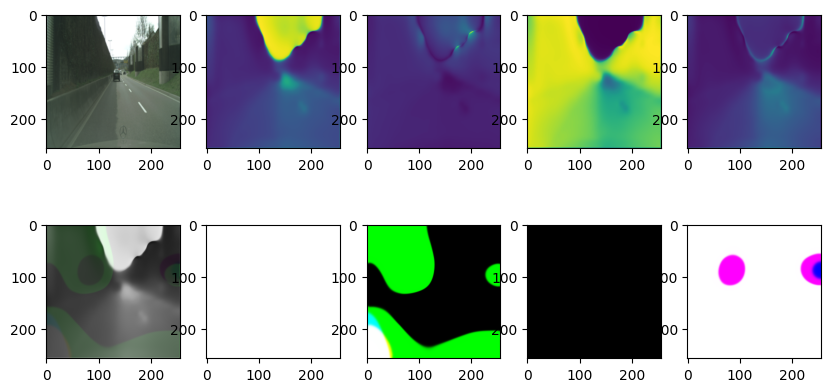

In [22]:
real ,_ = next(train_iter)
real = real.to(device)
with torch.no_grad():
    reconstruction, partial_reconstructions, segmentation, _ =      encode_image(real)
#     reconstructed_image = combine(reconstruction, segmentation)



components = segmentation.shape[1]
fig,ax = plt.subplots(2,components+1,figsize=(10,5))
real = scale_for_display(real)
ax[0,0].imshow(real[0].permute(1,2,0).cpu().numpy())
for i in range(components):
    ax[0,i+1].imshow(segmentation.cpu().numpy()[0,i])


# reconstructed_image = scale_for_display(reconstructed_image)
reconstruction = scale_for_display(reconstruction)
partial_reconstructions= scale_for_display(partial_reconstructions)
ax[1,0].imshow(reconstruction.cpu()[0].permute(1,2,0).numpy())
for i in range(components):
    ax[1,i+1].imshow(partial_reconstructions[0,i].permute(1,2,0).cpu().numpy())
plt.show()


In [ ]:

# 1. Independent Segmentation Path (Takes raw image because encoders are separated)
segmentation_logits = seg_gen(real)
segmentation = nn.Softmax(dim=1)(segmentation_logits)

# 2. Independent Reconstruction Encoder Path (Unpack the tuple!)
encoded_vector = enc(real)
norm = PixelNorm(encoded_vector.shape[1])
encoded_vector = norm(encoded_vector)

# 3. Composed Generation via SPADE
partial_reconstructions = gen(encoded_vector)

final_reconstruction = apply_segmentation(partial_reconstructions, segmentation)
# MUST return logits so entropy_loss_fn can use them stably
# return final_reconstruction, partial_reconstructions, segmentation, segmentation_logits
encoded_vector.max(), encoded_vector.min()

(tensor(0.2630, device='cuda:0', grad_fn=<MaxBackward1>),
 tensor(-0.2114, device='cuda:0', grad_fn=<MinBackward1>))

In [ ]:
encoded_vector
x  = gen.flatten_layer(encoded_vector)
x.shape

vectors = []
for vectorizer in gen.vectorizers:
    vectors.append(vectorizer(x))
vectors = torch.cat(vectors, dim=1)

In [ ]:
vectors.shape

torch.Size([16, 4, 512])